[*********************100%***********************]  1 of 1 completed


ADF Test Results:

kalman_returns p-value: 0.0000
price_returns p-value: 0.0000
obv p-value: 0.0000
std_dev p-value: 0.0004

VIF:
           feature       VIF
0  kalman_returns  1.814915
1             obv  1.848217
2         std_dev  1.030953


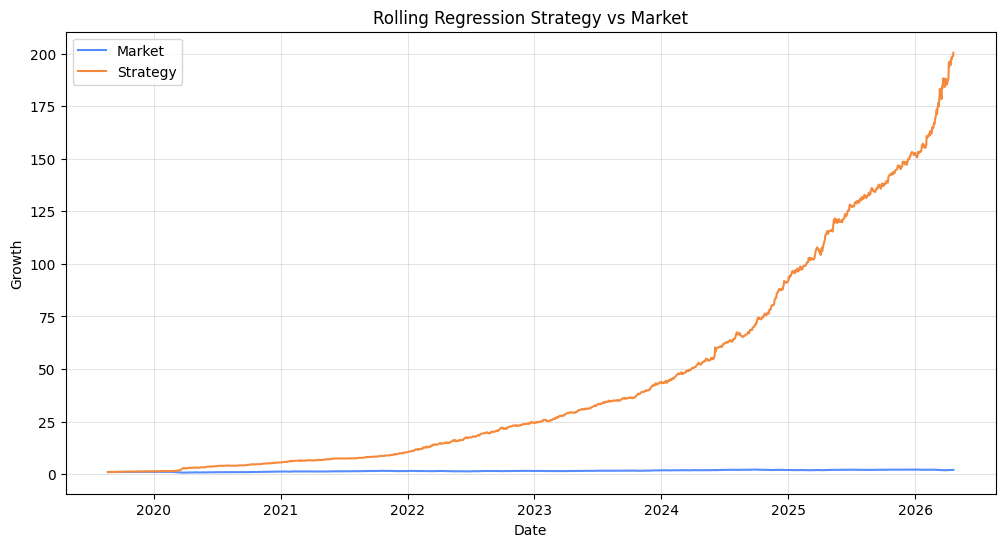

Hit Rate: 64.78%


In [2]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller
import statsmodels.graphics.tsaplots as sgt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pykalman import KalmanFilter


# -------------------------------
# 2. FEATURE FUNCTIONS
# -------------------------------

def calculate_obv(df):
    """
    On-Balance Volume (OBV)
    Measures buying/selling pressure using volume
    """
    obv = [0] * len(df)

    for i in range(1, len(df)):
        if df['Adj Close'].iloc[i] > df['Adj Close'].iloc[i-1]:
            obv[i] = obv[i-1] + df['Volume'].iloc[i]
        elif df['Adj Close'].iloc[i] < df['Adj Close'].iloc[i-1]:
            obv[i] = obv[i-1] - df['Volume'].iloc[i]
        else:
            obv[i] = obv[i-1]

    df['OBV'] = obv
    return df


def apply_kalman_filter(df, column='Adj Close'):
    """
    Smooth noisy price using Kalman Filter
    """
    kf = KalmanFilter(
        transition_matrices=[1],
        observation_matrices=[1],
        initial_state_mean=df[column].iloc[0],
        observation_covariance=1,
        transition_covariance=0.01
    )

    state_means, _ = kf.filter(df[column].values)
    df['Kalman_Price'] = state_means.flatten()

    return df


# -------------------------------
# 3. DOWNLOAD DATA
# -------------------------------

end = dt.date.today()
start = end - dt.timedelta(days=365*7)

df = yf.download('^NSEI', start=start, end=end, auto_adjust=False,multi_level_index=False)


# -------------------------------
# 4. FEATURE ENGINEERING
# -------------------------------

# OBV
df = calculate_obv(df)

# Kalman smoothing
df = apply_kalman_filter(df)

# Returns (log)
df['price_returns'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))
df['kalman_returns'] = np.log(df['Kalman_Price'] / df['Kalman_Price'].shift(1))

# Volatility (shift to avoid leakage)
df['std_dev'] = df['price_returns'].rolling(20).std().shift(1)

# Normalize OBV (rolling z-score)
window = 20
df['obv_mean'] = df['OBV'].rolling(window).mean()
df['obv_std'] = df['OBV'].rolling(window).std()
df['obv'] = (df['OBV'] - df['obv_mean']) / df['obv_std']

# Keep only required columns
df = df[['kalman_returns', 'price_returns', 'obv', 'std_dev']]
df.dropna(inplace=True)


# -------------------------------
# 5. STATIONARITY CHECK
# -------------------------------

print("ADF Test Results:\n")

for col in df.columns:
    result = adfuller(df[col])
    print(f"{col} p-value: {result[1]:.4f}")


# -------------------------------
# 6. FEATURE MATRIX
# -------------------------------

X = df[['kalman_returns', 'obv', 'std_dev']]
y = df['price_returns']


# -------------------------------
# 7. MULTICOLLINEARITY CHECK
# -------------------------------

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\nVIF:\n", vif_data)


# -------------------------------
# 8. ROLLING (WALK-FORWARD) MODEL
# -------------------------------

window = 60  # training window size

preds = []
actuals = []
dates = []

for i in range(window, len(y)):

    # Train on past data only
    X_train = X.iloc[i-window:i]
    y_train = y.iloc[i-window:i]

    # Predict next step
    X_test = X.iloc[i:i+1]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)[0]

    preds.append(y_pred)
    actuals.append(y.iloc[i])
    dates.append(y.index[i])


# -------------------------------
# 9. STRATEGY LOGIC
# -------------------------------

df_strat = pd.DataFrame({
    'Actual': actuals,
    'Predicted': preds
}, index=dates)

# Signal:
# +1 → long
# -1 → short
df_strat['Signal'] = np.sign(df_strat['Predicted'])

# Strategy returns
df_strat['Strategy_Return'] = df_strat['Signal'] * df_strat['Actual']


# -------------------------------
# 10. PERFORMANCE
# -------------------------------

df_strat['Market_Cum'] = (1 + df_strat['Actual']).cumprod()
df_strat['Strategy_Cum'] = (1 + df_strat['Strategy_Return']).cumprod()


# -------------------------------
# 11. PLOT EQUITY CURVE
# -------------------------------

plt.figure(figsize=(12,6))

plt.plot(df_strat['Market_Cum'], label='Market')
plt.plot(df_strat['Strategy_Cum'], label='Strategy')

plt.title('Rolling Regression Strategy vs Market')
plt.xlabel('Date')
plt.ylabel('Growth')

plt.legend()
plt.grid()

plt.show()


# -------------------------------
# 12. HIT RATE
# -------------------------------

hit_rate = np.mean(np.sign(df_strat['Actual']) == np.sign(df_strat['Predicted']))
print(f"Hit Rate: {hit_rate:.2%}")